<a href="https://colab.research.google.com/github/Elroux-06/PGM/blob/main/Copia_de_P4_LDPC_representation_(STUDENT_VERSION).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - LDPC Factor Graph Construction

This is the first of the two colab notebooks that form the project.

Here you will construct a **factor graph** for decoding a (regular)
**low-density parity-check (LDPC)** code. Although communication systems often
refer to messages and codewords, in this lab we model only the transmitted bits
$x$ and the channel outputs $y$. All other steps are either preprocessing
(encoding) or postprocessing (reading off the decoded bits).

As the block length $N$ increases, well-designed LDPC codes achieve better decoding performance, while the treewidth of the factor graph grows, making exact inference intractable and motivating approximate methods such as belief propagation.


## Learning goals

- Represent an LDPC code as a **factor graph** with:
  - binary **variable nodes** (bits),
  - **parity-check factors** (XOR constraints),
  - **channel factors** connecting each transmitted bit to its channel output.
- Validate the graph:
  - **structurally**: degrees, factor arities, correct wiring,
  - **semantically**: parity-check factors behave correctly on a known satisfying assignment.

You will be given:
- a generator for a *regular* parity-check matrix $H$ (with configurable density),
- a Binary Symmetric Channel (BSC) noise generator.

You will implement:
1. a parity-check factor constructor,
2. a channel factor constructor,
3. the factor-graph construction from $H$,
4. graph validation checks and visualization,
5. treewidth scaling analysis.

In [ ]:
# Colab setup
!pip -q install pgmpy networkx
!pip -q install matplotlib


In [18]:
import numpy as np
import itertools
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline
from pgmpy.models import FactorGraph
from pgmpy.factors.discrete import DiscreteFactor

# Factor graphs for Low-Density Parity-Check (LDPC) decoding

## Variables and factorization

The task is to transmit $N$ bits over a noisy channel. LDPC codes introduce $M$
parity-check constraints to enable error correction.

The factor graph contains two types of binary variables:
- **transmitted bits**: $x_0,\dots,x_{N-1}$
- **channel outputs**: $y_0,\dots,y_{N-1}$

The joint distribution defined by the factor graph factorizes as
$$
p(x,y)
\;\propto\;
\prod_{m=1}^M \psi_m\bigl(x_{N(m)}\bigr)
\;\;
\prod_{n=0}^{N-1} \phi_n(x_n, y_n),
$$

where $N(m)$ denotes the set of transmitted-bit indices that appear in factor
$\psi_m$, and:
- $\psi_m$ are **parity-check factors** enforcing local constraints on transmitted bits,
- $\phi_n$ are **channel factors** modeling the noise affecting each bit.

## Parity-check factors $\psi_m(x_{N(m)})$

Each parity-check factor enforces an even-parity constraint on a small subset of
transmitted bits.

Formally, the factor is defined as
$$
\psi_m\bigl(x_{N(m)}\bigr)
\;=\;
\begin{cases}
1 & \text{if } \sum_{n \in N(m)} x_n \equiv 0 \pmod 2, \\
0 & \text{otherwise}.
\end{cases}
$$

Thus, each parity-check factor is a **local constraint** that involves only the
$k$ transmitted-bit variables connected to it.

## Channel factors $\phi_n(x_n,y_n)$

Each channel factor connects a transmitted bit $x_n$ to its corresponding channel
output $y_n$.

We model the channel as a **binary symmetric channel (BSC)** with flip probability
$f$, defining
$$
\phi_n(x_n,y_n)
=
p(y_n \mid x_n)
=
\begin{cases}
1-f & \text{if } y_n = x_n, \\
f   & \text{if } y_n \neq x_n.
\end{cases}
$$

Channel factors are independent across bit positions.

## Decoding as inference

In a communication scenario, the channel outputs
$y_0,\dots,y_{N-1}$ are observed.

Decoding consists of inferring the transmitted bits
$x_0,\dots,x_{N-1}$ given these observations, that is, computing the posterior
distribution $p(x \mid y)$.

In the next session, you will approximate this posterior using belief propagation on the same factor graph, after introducing evidence on the $y$ variables.

## Regular LDPC parity-check matrix generator

A **regular LDPC code** is specified by a sparse parity-check matrix $H \in \{0,1\}^{M \times N},$which defines the structure of the parity-check factors in the factor graph.

- Each row corresponds to one parity-check factor.
- Each column corresponds to one transmitted-bit variable.
- Each row has exactly $k$ ones (each check involves $k$ bits).
- Each column has exactly $j$ ones (each bit participates in $j$ checks).

For a given row $m$, the set
$$
N(m) = \{\, n : H_{m,n} = 1 \,\}
$$
is exactly the set of transmitted bits connected to parity-check factor $\psi_m$.

The following code generates a random **regular LDPC** parity-check matrix:
- each **column** has weight $j$,
- each **row** has weight $k$.

If generation fails (rare for small sizes), re-run the cell or adjust the parameters.

In [3]:
def generate_regular_ldpc_H(N: int, j: int, k: int, seed: int = 0, max_tries: int = 2000) -> np.ndarray:
    """Generate a random (j,k)-regular binary parity-check matrix H of shape (M,N),
    where M = N*j/k must be an integer.

    Notes:
    - This construction is intentionally simple (sufficient for the lab).
    - It may create short cycles; that's fine (Lab 2 is loopy).
    """
    rng = np.random.default_rng(seed)
    if (N * j) % k != 0:
        raise ValueError(f"Need M = N*j/k integer, but N*j={N*j} not divisible by k={k}.")
    M = (N * j) // k

    for _ in range(max_tries):
        # Create j "stubs" per column
        col_stubs = np.repeat(np.arange(N), j)
        rng.shuffle(col_stubs)

        # Assign stubs into M groups of size k (rows)
        H = np.zeros((M, N), dtype=np.uint8)
        ok = True
        for m in range(M):
            cols = col_stubs[m * k : (m + 1) * k]
            # avoid duplicate variable in a single check (keeps row weight exactly k)
            if len(set(cols.tolist())) != k:
                ok = False
                break
            H[m, cols] = 1
        if not ok:
            continue

        # Verify regularity
        if np.all(H.sum(axis=0) == j) and np.all(H.sum(axis=1) == k):
            return H

    raise RuntimeError("Failed to construct a regular LDPC matrix. Try a different seed or parameters.")

## Part 1: Choose code parameters and generate $H$

Pick modest sizes so you can visualize and test easily.
Suggested starting point:
- $N=24$, $j=3$, $k=6$  (then $M=\frac{N j}{k} = 12$)

In [4]:
# TODO: Choose parameters
N = 24
j = 3
k = 6
seed_H = 0

H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed_H)
M = H.shape[0]
print(H)

print("H shape:", H.shape)
print("column weights (should all be j):", np.unique(H.sum(axis=0)))
print("row weights (should all be k):", np.unique(H.sum(axis=1)))

[[1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0]
 [0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0]
 [0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0]
 [0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0]
 [1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0]]
H shape: (12, 24)
column weights (should all be j): [3]
row weights (should all be k): [6]


## Part 2: Build factors

### 2.1 Parity-check factors $\psi_m(x_{N(m)})$

Implement `make_parity_check_factor` which receives a matrix $H$, a set of variables, and returns a factor defined over the transmitted-bit variables connected to that row.

It should be:
- value = 1 if the parity constraint is satisfied (even parity)
- value = 0 otherwise

Tips:
- With `DiscreteFactor`, you provide a `values` array of length $2^d$ (reshaped to `[2]*d`),
  where `d` is the number of variables in that factor.
- You can generate all assignments with `itertools.product([0,1], repeat=d)`.

<center>
<table>
  <thead>
    <tr>
      <th>$x_1$</th>
      <th>$x_2$</th>
      <th>$x_3$</th>
      <th>$\psi_{{123}}$</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>0</td><td>0</td><td>0</td><td>1</td></tr>
    <tr><td>0</td><td>0</td><td>1</td><td>0</td></tr>
    <tr><td>0</td><td>1</td><td>0</td><td>0</td></tr>
    <tr><td>0</td><td>1</td><td>1</td><td>1</td></tr>
    <tr><td>1</td><td>0</td><td>0</td><td>0</td></tr>
    <tr><td>1</td><td>0</td><td>1</td><td>1</td></tr>
    <tr><td>1</td><td>1</td><td>0</td><td>1</td></tr>
    <tr><td>1</td><td>1</td><td>1</td><td>0</td></tr>
  </tbody>
</table>
<br>Example of a 3-wise parity-check factor
</center>

In [8]:
def make_parity_check_factor(var_names):
    """Return a DiscreteFactor enforcing even parity over var_names.
    """
    
    d = len(var_names) # degree of the check node
    assignments = itertools.product([0, 1], repeat=d) # all possible binary assignments to the variables
    values = np.fromiter((1 if (sum(a) % 2 == 0) else 0 for a in assignments), dtype=int, count=2**d) # 1 for even parity, 0 for odd parity
    values = values.reshape([2] * d) # reshape to match the cardinality of the variables
    return DiscreteFactor(variables=var_names, cardinality=[2] * d, values=values) # create the factor with the specified variables, cardinality, and values
    # TODO: implement
            
    raise NotImplementedError


## Channel factors $\phi_n(x_n,y_n)$

Implement `make_bsc_channel_factor(x_var, y_var, f)`,
a **pairwise factor** over `(x_var, y_var)` defined by a **binary symmetric channel (BSC)** with flip probability $f$.

In [9]:
def make_bsc_channel_factor(x_var, y_var, f):
    """Pairwise channel factor for a BSC.
    Returns a DiscreteFactor over [x_var, y_var] with cardinalities [2,2].
    """
    if not (0.0 <= f <= 1.0):
        raise ValueError("Flip probability f must be in [0, 1].")

    values = np.array([
        [1 - f, f],  # x=0 -> y=0,1
        [f, 1 - f],  # x=1 -> y=0,1
    ], dtype=float)

    return DiscreteFactor(
        variables=[x_var, y_var],
        cardinality=[2, 2],
        values=values
    )
    # TODO: implement
    raise NotImplementedError

## Part 3: Create the factor graph from $H$

Construct a `pgmpy` `FactorGraph`:

1. add variable nodes: `x0...x{N-1}`
2. add parity-check factors (one per row of H) and connect them
3. (optional today, required later) add likelihood factors and connect them

Implement:
- `build_ldpc_factor_graph(H, y=None, f=None)`

In [10]:
def build_ldpc_factor_graph(H: np.ndarray, f: float) -> FactorGraph:
    """Build an LDPC factor graph with explicit channel-output variables.

    Variables:
      - transmitted bits: x0..x{N-1}
      - channel outputs:  y0..y{N-1}

    Factors:
      - parity-check factors on x's (from H)
      - channel factors φ_n(x_n, y_n) = p(y_n | x_n) for BSC flip prob f

    Evidence (a particular received word Y) will be introduced later by clamping y's.
    """
    M, N = H.shape
    x_vars = [f"x{n}" for n in range(N)]
    y_vars = [f"y{n}" for n in range(N)]

    G = FactorGraph()

    # 1) Add variable nodes

    # 2) Add parity-check factors (one per row of H) and connect them

    # 3) Add channel factors φ_n(x_n, y_n) and connect them
    G.add_nodes_from(x_vars + y_vars)

    for m in range(M):
      idx = np.where(H[m] == 1)[0]
      scope = [x_vars[n] for n in idx]
      parity_factor = make_parity_check_factor(scope)
      G.add_factors(parity_factor)
      G.add_nodes_from([parity_factor])
      G.add_edges_from((v, parity_factor) for v in scope)

    for n in range(N):
      channel_factor = make_bsc_channel_factor(x_vars[n], y_vars[n], f)
      G.add_factors(channel_factor)
      G.add_nodes_from([channel_factor])
      G.add_edges_from([(x_vars[n], channel_factor), (y_vars[n], channel_factor)])
    return G

## Part 4: Validating the factor graph

We must verify that the factor graph correctly represents the intended LDPC model.

Your task in this part is to **think about validations that make
sense**, and to implement some of them.

Examples of questions you may consider include:
### Structural checks:

- Does the number and type of factors match the specification of the LDPC code?
- Are parity-check factors connected to the correct subsets of transmitted bits?
- Do variable nodes have the expected degrees (for a regular code)?
- Do parity-check factors behave correctly on a known satisfying assignment?
### Semantic checks:
For small $N$, you can test the parity-check factors exhaustively.

For each assignment $x \in \{0,1\}^N$ (there are $2^N$ of them), compute the so-called *syndrome*
$$
s = Hx \pmod 2.
$$
The parity-check constraints are satisfied if and only if $s=0$, so the product of
all parity-check factors should evaluate to
$$
\prod_{m=1}^M \psi_m(x_{N(m)}) =
\begin{cases}
1 & \text{if } Hx \equiv 0 \pmod 2,\\
0 & \text{otherwise.}
\end{cases}
$$

For this semantic test you can ignore the $y$ variables and the channel factors.


In [13]:
def validate_ldpc_graph(G,H,num_trials):
    """Basic validation of an LDPC factor graph.

    This function performs a minimal sanity check using G.check_code().
    Students are encouraged to extend it with additional structural or
    semantic validations.
    """
    assert G.check_model(), "Basic LDPC graph validation failed."

    # TODO:
    # Add additional checks, for example:
    # - number of variable and factor nodes
    # - degrees of x and y variables
    # - parity-check factor arities
    # - behavior of parity-check factors on a known satisfying assignment
    # ...
    M, N = H.shape

    # Expected variable names
    x_vars = [f"x{n}" for n in range(N)]
    y_vars = [f"y{n}" for n in range(N)]

    #We check the number of variables here, as we have N transmitted xn bits and N response bits, the total number of nodes in the graph should be 2*N
    variable_nodes = [n for n in G.nodes() if isinstance(n, str)]
    assert len(variable_nodes) == 2 * N, \
        "Unexpected number of variable nodes."
    #Now we check the degrees of each node
    #transmitted xn bits will have  exactly  degree j+1  j parity check factor nodes (stated at the beggining,each transmitted bit participates in j parity check constraints)
    # and 1 channel factor with yn
    for x in x_vars:
        deg = len(list(G.neighbors(x)))
        assert deg == j + 1, \
            f"{x} has degree {deg}, expected {j+1}"

    # y_n should have degree 1 (only channel factor)
    for y in y_vars:
        deg = len(list(G.neighbors(y)))
        assert deg == 1, \
            f"{y} has degree {deg}, expected 1"

    # We first get all factors from the graph
    factors = list(G.get_factors())

    # We separate parity and channel factors
    parity_factors = []
    channel_factors = []

    for f in factors:
       
        if all(v.startswith("x") for v in f.variables):  # Parity factors involve only x variables (only transmitted xn bits) , its a local constraint
            parity_factors.append(f)
       
        elif len(f.variables) == 2:  # Channel factors involve exactly one x and one y
            channel_factors.append(f)

    # We now check correct number of factors
    assert len(parity_factors) == M, "Wrong number of parity factors." #The nuber of expected parity check factors is the number of rows of H
    assert len(channel_factors) == N, "Wrong number of channel factors." #The number of expected channel factors is the number of transmitted bits N.

    # We check parity scopes match rows of H
    for m in range(M):
        expected_scope = {f"x{n}" for n in np.where(H[m] == 1)[0]} #We get the expected nodes (xn) that should be connected on the parity factor m

        found = False
        for f in parity_factors:
            if set(f.variables) == expected_scope: #we check if they match
                found = True
                break

        assert found, f"Parity factor for row {m} does not match H."

    # 5) Simple semantic check (random assignments)
    for _ in range(50):
        x = np.random.randint(0, 2, size=N)

        # Compute syndrome
        syndrome_ok = np.all((H @ x) % 2 == 0)

        # Compute product of parity factors
        prod_val = 1
        for f in parity_factors:
            assign = {v: int(x[int(v[1:])]) for v in f.variables}
            prod_val *= f.get_value(**assign)

        assert (prod_val == 1) == syndrome_ok, "Parity semantics mismatch."

    return True

N = 24
j = 3
k = 6
seed_H = 0
H = generate_regular_ldpc_H(N=N, j=j, k=k, seed=seed_H)
G = build_ldpc_factor_graph(H, f=0.8)
validate_ldpc_graph(G, H, 10000)


True

## Part 5: Visualization

Implement code that visualizes a factor graph.

You can use `networkx` and `matplotlib.pyplot`, and all the functions from that library such as `nx.draw_networkx_nodes`


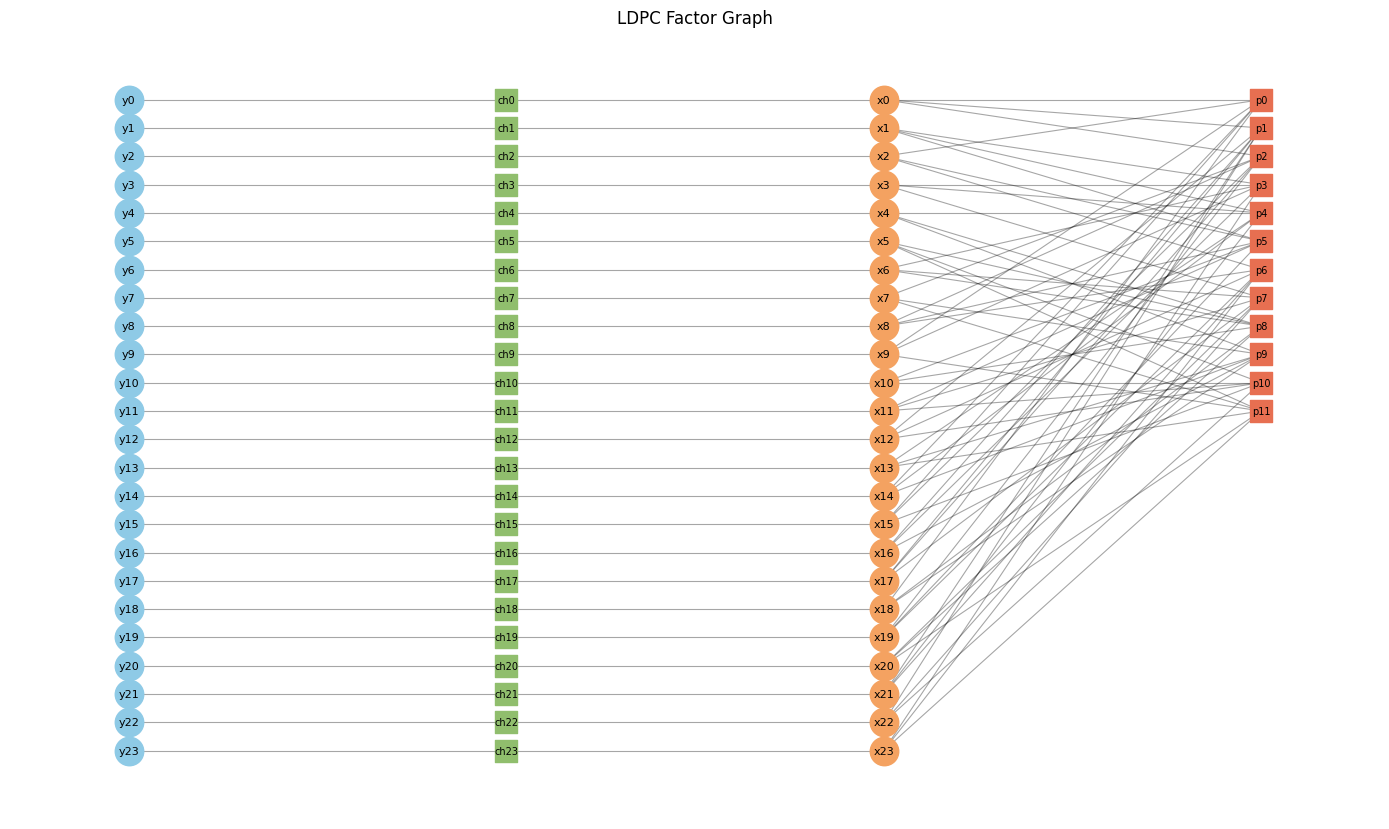

In [ ]:

import networkx as nx
from pgmpy.models import FactorGraph

def visualize_factor_graph(G: FactorGraph, max_nodes: int = 200):
    """Visualize an LDPC factor graph with a fixed column layout.

    Columns (left to right):
      y variables → channel factors → x variables → parity-check factors
    """
    Hnx = nx.Graph()
    Hnx.add_nodes_from(G.nodes())
    Hnx.add_edges_from(G.edges())

    def _var_idx(v):
      return int(v[1:]) if isinstance(v, str) and v[1:].isdigit() else 0

    x_vars = sorted([n for n in Hnx.nodes if isinstance(n, str) and n.startswith("x")], key=_var_idx)
    y_vars = sorted([n for n in Hnx.nodes if isinstance(n, str) and n.startswith("y")], key=_var_idx)
    factor_nodes = [n for n in Hnx.nodes if not isinstance(n, str)]

    channel_factors, parity_factors = [], []
    for f in factor_nodes:
      scope = list(getattr(f, "variables", []))
      if len(scope) == 2 and any(v.startswith("x") for v in scope) and any(v.startswith("y") for v in scope):
        channel_factors.append(f)
      elif all(v.startswith("x") for v in scope):
        parity_factors.append(f)

    channel_factors = sorted(
      channel_factors,
      key=lambda f: min(_var_idx(v) for v in f.variables if v.startswith("x"))
    )
    parity_factors = sorted(
      parity_factors,
      key=lambda f: min(_var_idx(v) for v in f.variables if v.startswith("x"))
    )

    if Hnx.number_of_nodes() > max_nodes:
      keep_x = set(x_vars[: max_nodes // 4])
      keep_y = set(y_vars[: max_nodes // 4])
      keep_vars = keep_x | keep_y
      keep_factors = {
        f for f in factor_nodes
        if set(getattr(f, "variables", [])).issubset(keep_vars)
      }
      Hnx = Hnx.subgraph(keep_vars | keep_factors).copy()
      x_vars = [v for v in x_vars if v in Hnx]
      y_vars = [v for v in y_vars if v in Hnx]
      channel_factors = [f for f in channel_factors if f in Hnx]
      parity_factors = [f for f in parity_factors if f in Hnx]

    pos = {}
    for i, y in enumerate(y_vars):
      pos[y] = (0, -i)
    for i, cf in enumerate(channel_factors):
      pos[cf] = (1, -i)
    for i, x in enumerate(x_vars):
      pos[x] = (2, -i)
    for i, pf in enumerate(parity_factors):
      pos[pf] = (3, -i)

    plt.figure(figsize=(14, max(6, 0.35 * max(len(x_vars), len(parity_factors)))))
    nx.draw_networkx_edges(Hnx, pos, width=0.8, alpha=0.35)

    nx.draw_networkx_nodes(Hnx, pos, nodelist=y_vars, node_color="#8ecae6", node_size=420, node_shape="o")
    nx.draw_networkx_nodes(Hnx, pos, nodelist=channel_factors, node_color="#90be6d", node_size=260, node_shape="s")
    nx.draw_networkx_nodes(Hnx, pos, nodelist=x_vars, node_color="#f4a261", node_size=420, node_shape="o")
    nx.draw_networkx_nodes(Hnx, pos, nodelist=parity_factors, node_color="#e76f51", node_size=260, node_shape="s")

    var_labels = {v: v for v in (x_vars + y_vars)}
    ch_labels = {f: f"ch{i}" for i, f in enumerate(channel_factors)}
    p_labels = {f: f"p{i}" for i, f in enumerate(parity_factors)}

    nx.draw_networkx_labels(Hnx, pos, labels=var_labels, font_size=8)
    nx.draw_networkx_labels(Hnx, pos, labels=ch_labels | p_labels, font_size=7)

    plt.title("LDPC Factor Graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    # TODO:
    # visualize the graph


H = generate_regular_ldpc_H(N=24, j=3, k=6, seed=1)
G = build_ldpc_factor_graph(H, f=0.8)
visualize_factor_graph(G)


## Part 6: Treewidth scaling with block length $N$

To study how inference complexity scales with the block length $N$, we analyze the **treewidth** of the LDPC code.

We first construct the **primal graph** on the transmitted bits $x_0,\dots,x_{N-1}$: this is an undirected graph in which two bits are connected by an edge if they appear together in any parity-check factor. It is analogous to moralization, but applied to a factor graph rather than a Bayesian network.

Since computing treewidth exactly is NP-hard, we estimate it using a
**min-fill heuristic**, which provides an upper bound on the treewidth.

Use `networkx.algorithms.approximation.treewidth_min_fill_in` to estimate the
treewidth of the primal graph for increasing values of $N$, and plot the result. When do you think inference will start being intractable?

In [ ]:
from networkx.algorithms.approximation import treewidth_min_fill_in

def ldpc_primal_graph_on_x(G):
    """Build the primal graph on x-variables only.

    Nodes: x0..x{N-1}
    Edge between xi and xj if some parity-check factor contains both.
    """
    # TODO:
    # - create an undirected NetworkX graph
    # - add one node per x-variable
    # - for each parity-check factor, connect all x-variables that appear together
    raise NotImplementedError


def treewidth_scaling_experiment(N_list, j, k, f=0.08, seed0=0):
    """Estimate treewidth scaling for increasing block lengths N.

    Returns a list of tuples (N, estimated_treewidth, num_edges).
    """
    # TODO:
    # - for each N:
    #   - generate a regular LDPC parity-check matrix H
    #   - build the LDPC factor graph
    #   - construct the primal graph on x-variables
    #   - estimate treewidth using networkx.treewidth_min_fill_in
    # - return the collected results
    raise NotImplementedError

N_list = [12, 18, 24, 30, 36, 42, 50]
j, k = 3, 6
tw_results = treewidth_scaling_experiment(N_list, j=j, k=k, f=0.08, seed0=0)
tw_results